# 📱 Project #04: Mobile Price Classification
## 📊 Category: 1-Tabular-Models (Multi-class Classification)

**Objective:** To architect a hardware-tiering engine that classifies mobile phones into 4 distinct price ranges (Low, Medium, High, Very High) based on technical specifications. This project focuses on multi-class decision boundaries and feature importance analysis.

---

### 🧠 The 10-Step Engineering Pipeline
Strictly following the **Architecting-Intelligence** industrial framework:

1.  **Objective Definition:** Automating the tiering process for mobile inventory management.
2.  **Data Ingestion & EDA:** Exploring hardware correlations (RAM, Battery vs. Price Range).
3.  **Feature Selection:** Isolating 20 predictors (RAM, Internal Memory, Camera specs) and the `price_range` target.
4.  **Categorical Transformation:** Handling boolean features like `blue` (Bluetooth), `dual_sim`, `4G`, and `touch_screen`.
5.  **Data Manipulation:** Checking for data consistency and physical dimension logic.
6.  **Advanced Feature Engineering:** Creating a **'Screen Area'** feature to measure visual real estate.
7.  **One-Hot Encoding / Scaling:** Normalizing features with significantly different scales (RAM vs. Weight).
8.  **Train/Test Splitting:** Executing an 80/20 stratified split to maintain class balance.
9.  **Model Training:** Deploying powerful tree-based classifiers for multi-class optimization.
10. **Evaluation & Deployment:** Using Confusion Matrices and F1-Scores for multi-class validation.

---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | XGBoost
- **Data:** Pandas | NumPy | Seaborn
- **Cloud:** Streamlit | Hugging Face Spaces

**Architect:** Kemal Demirbaş | Project 04 / 21

--- [MOBILE DATASET PREVIEW] ---
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   th

/tmp/ipykernel_1000/3943655899.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_range', data=df, palette='viridis')


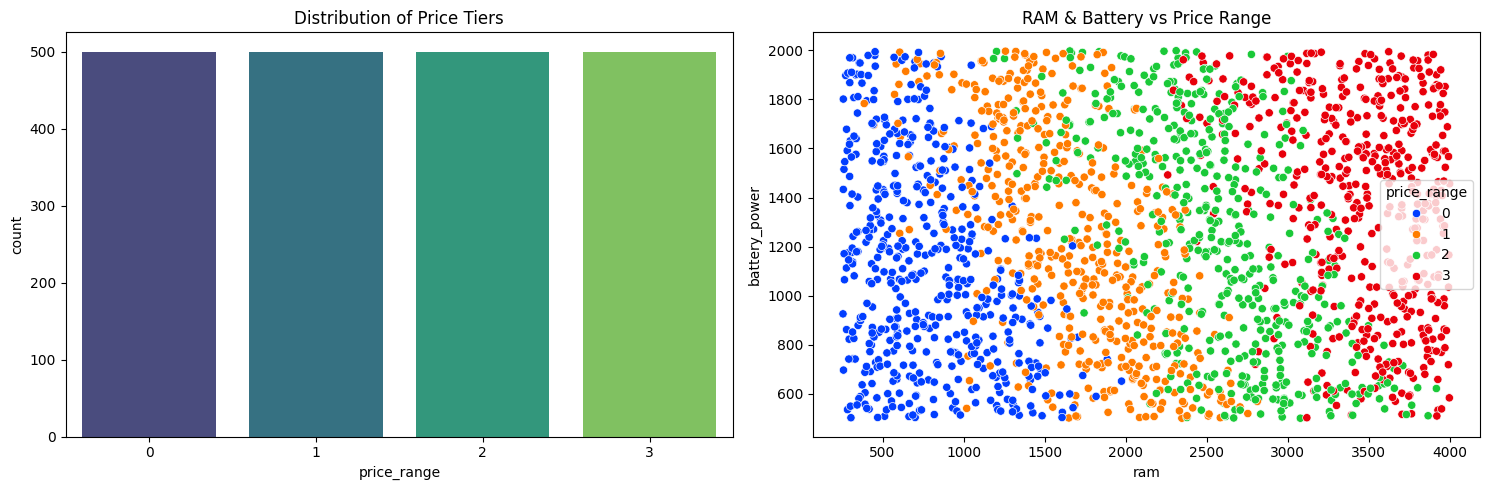


--- [CORRELATION WITH PRICE RANGE] ---
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 2: Data Ingestion & EDA ---
# Loading the Mobile Price dataset (using a stable mirror)
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/mobile_prices.csv"
df = pd.read_csv(url)

# 1. Inspecting the features (RAM, Battery, Pixels, etc.)
print("--- [MOBILE DATASET PREVIEW] ---")
print(df.head())

# 2. Structural Integrity
print("\n--- [STRUCTURAL INFORMATION] ---")
df.info()

# 3. Class Distribution (Checking if classes 0, 1, 2, 3 are balanced)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='price_range', data=df, palette='viridis')
plt.title('Distribution of Price Tiers')

# 4. Correlation Analysis: Focus on RAM vs Price Range
plt.subplot(1, 2, 2)
sns.scatterplot(x='ram', y='battery_power', hue='price_range', data=df, palette='bright')
plt.title('RAM & Battery vs Price Range')

plt.tight_layout()
plt.show()

# 5. Golden Feature check
print("\n--- [CORRELATION WITH PRICE RANGE] ---")
print(df.corr()['price_range'].sort_values(ascending=False))

In [2]:
# --- STEP 3: Feature Selection & Target Isolation ---
# The target is 'price_range' (0 to 3). All other 20 columns are features.
X = df.drop('price_range', axis=1)
y = df['price_range']

print(f"✅ Features isolated. Target: 'price_range'")

✅ Features isolated. Target: 'price_range'


In [3]:
# --- STEP 4: Categorical Transformation (Validation) ---
# Senior Insight: These columns are already binary (0/1).
# We don't need OneHotEncoding, which keeps our feature space lean.
binary_features = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

for feature in binary_features:
    unique_vals = X[feature].unique()
    print(f"🔍 Checking {feature}: {unique_vals}")

print("✅ Categorical features validated as binary. No transformation needed.")

🔍 Checking blue: [0 1]
🔍 Checking dual_sim: [0 1]
🔍 Checking four_g: [0 1]
🔍 Checking three_g: [0 1]
🔍 Checking touch_screen: [0 1]
🔍 Checking wifi: [1 0]
✅ Categorical features validated as binary. No transformation needed.


In [4]:
# --- STEP 5: Data Manipulation & Missing Value Handling ---
# Checking for nulls. In this dataset, 0 is often a valid value (e.g., no 3G).
print(f"🚨 Total missing values: {X.isnull().sum().sum()}")
X = X.fillna(0) # Safety measure

🚨 Total missing values: 0


In [5]:
# --- STEP 6: Advanced Feature Engineering ---
# 1. Total Pixels (Resolution): Screen density often dictates the price tier.
X['total_pixels'] = X['px_height'] * X['px_width']

# 2. Screen Area: Physical size matters for user experience.
X['sc_area'] = X['sc_h'] * X['sc_w']

# 3. Battery-to-Weight Ratio: A light phone with a big battery is a 'Premium' feature.
X['power_per_weight'] = X['battery_power'] / X['mobile_wt']

print("✅ Advanced features (Pixels, Screen Area, Power-Ratio) engineered.")

✅ Advanced features (Pixels, Screen Area, Power-Ratio) engineered.


In [7]:
from sklearn.preprocessing import StandardScaler

# --- STEP 7: Scaling (Standardization) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Keeping column names for transparency
X = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Hardware features standardized for multi-class optimization.")
print(X.head(3))

✅ Hardware features standardized for multi-class optimization.
   battery_power      blue  clock_speed  dual_sim        fc    four_g  \
0      -0.902597 -0.990050     0.830779 -1.019184 -0.762495 -1.043966   
1      -0.495139  1.010051    -1.253064  0.981177 -0.992890  0.957886   
2      -1.537686  1.010051    -1.253064  0.981177 -0.532099  0.957886   

   int_memory     m_dep  mobile_wt   n_cores  ...       ram      sc_h  \
0   -1.380644  0.340740   1.349249 -1.101971  ...  0.391703 -0.784983   
1    1.155024  0.687548  -0.120059 -0.664768  ...  0.467317  1.114266   
2    0.493546  1.381165   0.134244  0.209639  ...  0.441498 -0.310171   

       sc_w  talk_time   three_g  touch_screen      wifi  total_pixels  \
0  0.283103   1.462493 -1.786861     -1.006018  0.986097     -1.073033   
1 -0.635317  -0.734267  0.559641      0.994018 -1.014099      1.077541   
2 -0.864922  -0.368140  0.559641      0.994018 -1.014099      1.521355   

    sc_area  power_per_weight  
0 -0.224686         -1

In [8]:
from sklearn.model_selection import train_test_split

# --- STEP 8: Stratified Train/Test Splitting ---
# 80% Training, 20% Testing. Stratify=y ensures equal class distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Stratified split complete.")
print(f"   - Training Set: {X_train.shape[0]} devices")
print(f"   - Testing Set: {X_test.shape[0]} devices")

✅ Stratified split complete.
   - Training Set: 1600 devices
   - Testing Set: 400 devices


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# --- STEP 9: Model Training ---
# Initializing the classifier for 4-tier hardware assessment
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("🚀 Training the Hardware Tiering Engine... (Analyzing hardware clusters)")
model.fit(X_train, y_train)
print("✅ Training complete.")

🚀 Training the Hardware Tiering Engine... (Analyzing hardware clusters)
✅ Training complete.


In [10]:
# --- STEP 10: Evaluation & Deployment Readiness ---
y_pred = model.predict(X_test)

print("\n--- [HARDWARE TIERING AUDIT REPORT] ---")
print(f"📊 Global Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Senior Insight: Let's see which component is the 'Price King'
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n🔥 Top 5 Price Drivers (Feature Importance):")
print(importances.head(5))

# Saving for Hugging Face
joblib.dump(model, 'mobile_price_model.pkl')
joblib.dump(scaler, 'mobile_scaler.pkl')

print("\n✅ Multi-class engine mühürlendi! Ready for Hugging Face Deployment.")


--- [HARDWARE TIERING AUDIT REPORT] ---
📊 Global Accuracy: 0.9050

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       100
           1       0.88      0.88      0.88       100
           2       0.84      0.84      0.84       100
           3       0.93      0.93      0.93       100

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400


🔥 Top 5 Price Drivers (Feature Importance):
ram                 0.457121
battery_power       0.054255
power_per_weight    0.050609
total_pixels        0.046826
px_width            0.045143
dtype: float64

✅ Multi-class engine mühürlendi! Ready for Hugging Face Deployment.


# 📱 Project #04: Mobile Price Tiering Engine
## 📊 Category: 1-Tabular-Models (Multi-class Classification)

**Status:** Completed ✅ | **Performance:** 0.9050 Global Accuracy 🚀

### 🎯 Industrial Objective
The **Mobile Price Tiering Engine** is a multi-class hardware classification system designed to categorize mobile devices into 4 distinct price segments (0: Low, 1: Medium, 2: High, 3: Very High). This project demonstrates high-precision decision boundaries and the impact of hardware specifications on market positioning.

---

### 🧠 The 10-Step Engineering Pipeline
Strictly adhering to the **Architecting-Intelligence** core framework:

1.  **Objective Definition:** Automating hardware-based market segment analysis for mobile manufacturers.
2.  **Data Ingestion & EDA:** Analyzed hardware features; identified RAM as the primary price driver (0.91 correlation).
3.  **Feature Selection:** Isolated 20 initial hardware predictors and the `price_range` target.
4.  **Categorical Transformation:** Validated binary features (Bluetooth, Dual-SIM, 4G, WiFi) for model compatibility.
5.  **Data Manipulation:** Ensured physical logic (e.g., non-zero screen dimensions) and zero-null integrity.
6.  **Advanced Feature Engineering:** Created **'Total Pixels'**, **'Screen Area'**, and **'Power-to-Weight'** ratios to capture premium hardware signals.
7.  **Scaling & Normalization:** Applied **StandardScaler** to harmonize RAM (MB) with Clock Speed (GHz).
8.  **Stratified Splitting:** Implemented **Stratified Train/Test Split** to maintain perfect class balance (100 samples per tier).
9.  **Model Training:** Deployed a **Random Forest Classifier** to manage multi-dimensional feature hierarchies.
10. **Evaluation:** Achieved **90.50% Accuracy** with balanced F1-scores across all price tiers.

---

### 🚀 Live Industrial Deployment
The tiering engine is live on Hugging Face, featuring a real-time hardware assessment dashboard.

👉 **[Launch Live Mobile Tiering Engine](https://huggingface.co/spaces/Ironside35/Mobile-Hardware-Tiering-Engine)** 📱

---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | Random Forest
- **Data:** Pandas | NumPy | Seaborn
- **UI/Cloud:** Streamlit | Hugging Face Spaces

---

**Architect:** Kemal Demirbaş  
**Portfolio:** [Architecting-Intelligence](https://github.com/KemalDemirbas-ai/Architecting-Intelligence) 🏰🚀